In [1]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multitest import multipletests

In [2]:
# setup
root = "C:/Users/andre/IdeaProjects/llm-moral-distractors-working/"
np.seterr(all='raise')

result_configs = [
    (
        "data/csv_results/main/reddit/openai_gpt-4.1_reddit_probs.csv",
        "GPT-4.1 reddit probs"
    )
]

In [3]:
def calculate_results(
        response_df_filename,
        distractor_df_filename="data/distractors.csv"
):
    response_df = pd.read_csv(root + response_df_filename)
    
    # Remove all distractor scenarios where baseline scenario is invalid
    invalid_ids = response_df.loc[(response_df["esh_prob"] + response_df["yta_prob"] + response_df["nta_prob"] + response_df["nah_prob"] + response_df["info_prob"] == 0), "scenario_id"].tolist()
    response_df = response_df.loc[~response_df["scenario_id"].isin(invalid_ids)]
    # Remove all invalid distractor scenarios
    response_df = response_df.loc[(response_df["esh_prob"] + response_df["yta_prob"] + response_df["nta_prob"] + response_df["nah_prob"] + response_df["info_prob"] != 0)]
    
    # Join with scenario and distractor df
    distractor_df = pd.read_csv(root + distractor_df_filename)
    response_df =  response_df.merge(distractor_df, left_on="distractor_id", right_on="id", how='left')

    distractor_dfs = {
        "baseline": response_df.loc[(pd.isna(response_df["sentiment"]))],
        "positive": response_df.loc[(response_df['sentiment'] == 'positive')],
        "neutral": response_df.loc[(response_df['sentiment'] == 'neutral')],
        "negative": response_df.loc[(response_df['sentiment'] == 'negative')]
    }
    
    # Calculate mean prob difference, standard error, and p-vals
    results = {}
    
    # Calculate for distractor conditions
    for k, df in distractor_dfs.items():
        df_merge = df.merge(distractor_dfs["baseline"][["scenario_id", "esh_prob", "yta_prob", "nta_prob", "nah_prob", "info_prob"]], on="scenario_id", how="left", suffixes=["_distractor", "_baseline"])  # set baseline comparison distribution

        df_merge["total_prob_distractor"] = df_merge["esh_prob_distractor"] + df_merge["yta_prob_distractor"] + df_merge["nta_prob_distractor"] + df_merge["nah_prob_distractor"] + df_merge["info_prob_distractor"]
        df_merge["mp_esh_distractor"] = df_merge["esh_prob_distractor"] / df_merge["total_prob_distractor"]
        df_merge["mp_yta_distractor"] = df_merge["yta_prob_distractor"] / df_merge["total_prob_distractor"]
        df_merge["mp_nta_distractor"] = df_merge["nta_prob_distractor"] / df_merge["total_prob_distractor"]
        df_merge["mp_nah_distractor"] = df_merge["nah_prob_distractor"] / df_merge["total_prob_distractor"]
        df_merge["mp_info_distractor"] = df_merge["info_prob_distractor"] / df_merge["total_prob_distractor"]
        
        df_merge["total_prob_baseline"] = df_merge["esh_prob_baseline"] + df_merge["yta_prob_baseline"] + df_merge["nta_prob_baseline"] + df_merge["nah_prob_baseline"] + df_merge["info_prob_baseline"]
        df_merge["mp_esh_baseline"] = df_merge["esh_prob_baseline"] / df_merge["total_prob_baseline"]
        df_merge["mp_yta_baseline"] = df_merge["yta_prob_baseline"] / df_merge["total_prob_baseline"]
        df_merge["mp_nta_baseline"] = df_merge["nta_prob_baseline"] / df_merge["total_prob_baseline"]
        df_merge["mp_nah_baseline"] = df_merge["nah_prob_baseline"] / df_merge["total_prob_baseline"]
        df_merge["mp_info_baseline"] = df_merge["info_prob_baseline"] / df_merge["total_prob_baseline"]
        
        df_merge["mp_diff_esh"] = df_merge["mp_esh_distractor"] - df_merge["mp_esh_baseline"]
        df_merge["mp_diff_yta"] = df_merge["mp_yta_distractor"] - df_merge["mp_yta_baseline"]
        df_merge["mp_diff_nta"] = df_merge["mp_nta_distractor"] - df_merge["mp_nta_baseline"]
        df_merge["mp_diff_nah"] = df_merge["mp_nah_distractor"] - df_merge["mp_nah_baseline"]
        df_merge["mp_diff_info"] = df_merge["mp_info_distractor"] - df_merge["mp_info_baseline"]
        
        df_result = df_merge[["mp_esh_distractor", "mp_yta_distractor", "mp_nta_distractor", "mp_nah_distractor", "mp_info_distractor",
                              "mp_esh_baseline", "mp_yta_baseline", "mp_nta_baseline", "mp_nah_baseline", "mp_info_baseline",
                              "mp_diff_esh", "mp_diff_yta", "mp_diff_nta", "mp_diff_nah", "mp_diff_info"]]
        results[k] = df_result
    
    mean_mps = {}
    mean_mp_diffs = {}
    std_mps = {}
    std_mp_diffs = {}
    st_error_mps = {}
    st_error_mp_diffs = {}
    sig_mps = {}
    
    for distractor, df in results.items():
        mean_mps[distractor] = {
            "esh": np.mean(df["mp_esh_distractor"]),
            "yta": np.mean(df["mp_yta_distractor"]),
            "nta": np.mean(df["mp_nta_distractor"]),
            "nah": np.mean(df["mp_nah_distractor"]),
            "info": np.mean(df["mp_info_distractor"])
        }
        mean_mp_diffs[distractor] = {
            "esh": np.mean(df["mp_diff_esh"]),
            "yta": np.mean(df["mp_diff_yta"]),
            "nta": np.mean(df["mp_diff_nta"]),
            "nah": np.mean(df["mp_diff_nah"]),
            "info": np.mean(df["mp_diff_info"])
        }
        std_mps[distractor] = {
            "esh": np.std(df["mp_esh_distractor"]),
            "yta": np.std(df["mp_yta_distractor"]),
            "nta": np.std(df["mp_nta_distractor"]),
            "nah": np.std(df["mp_nah_distractor"]),
            "info": np.std(df["mp_info_distractor"])
        }
        std_mp_diffs[distractor] = {
            "esh": np.std(df["mp_diff_esh"]),
            "yta": np.std(df["mp_diff_yta"]),
            "nta": np.std(df["mp_diff_nta"]),
            "nah": np.std(df["mp_diff_nah"]),
            "info": np.std(df["mp_diff_info"])
        }
        st_error_mps[distractor] = {
            "esh": np.std(df["mp_esh_distractor"]) / np.sqrt(len(df["mp_esh_distractor"])),
            "yta": np.std(df["mp_yta_distractor"]) / np.sqrt(len(df["mp_yta_distractor"])),
            "nta": np.std(df["mp_nta_distractor"]) / np.sqrt(len(df["mp_nta_distractor"])),
            "nah": np.std(df["mp_nah_distractor"]) / np.sqrt(len(df["mp_nah_distractor"])),
            "info": np.std(df["mp_info_distractor"]) / np.sqrt(len(df["mp_info_distractor"]))
        }
        st_error_mp_diffs[distractor] = {
            "esh": np.std(df["mp_diff_esh"]) / np.sqrt(len(df["mp_diff_esh"])),
            "yta": np.std(df["mp_diff_yta"]) / np.sqrt(len(df["mp_diff_yta"])),
            "nta": np.std(df["mp_diff_nta"]) / np.sqrt(len(df["mp_diff_nta"])),
            "nah": np.std(df["mp_diff_nah"]) / np.sqrt(len(df["mp_diff_nah"])),
            "info": np.std(df["mp_diff_info"]) / np.sqrt(len(df["mp_diff_info"]))
        }
    
    for distractor in ["positive", "neutral", "negative"]:
        df = results[distractor]
        sig_mps[distractor] = {
            "esh": stats.ttest_rel(df["mp_esh_distractor"], df["mp_esh_baseline"]),
            "yta": stats.ttest_rel(df["mp_yta_distractor"], df["mp_yta_baseline"]),
            "nta": stats.ttest_rel(df["mp_nta_distractor"], df["mp_nta_baseline"]),
            "nah": stats.ttest_rel(df["mp_nah_distractor"], df["mp_nah_baseline"]),
            "info": stats.ttest_rel(df["mp_info_distractor"], df["mp_info_baseline"])
        }
    
    return mean_mps, mean_mp_diffs, std_mps, std_mp_diffs, st_error_mps, st_error_mp_diffs, sig_mps

In [4]:
mean_mp_dict = {}
mean_mp_diff_dict = {}
st_error_mp_dict = {}
st_error_mp_diff_dict = {}
sig_dict = {}

for config in result_configs:
    response_df_filename, figure_name = config
    mean_mps, mean_mp_diffs, std_mps, std_mp_diffs, st_error_mps, st_error_mp_diffs, sig_mps = calculate_results(
        response_df_filename
    )
    
    mean_mp_dict[figure_name] = mean_mps
    mean_mp_diff_dict[figure_name] = mean_mp_diffs

    st_error_mp_dict[figure_name] = st_error_mps
    st_error_mp_diff_dict[figure_name] = st_error_mp_diffs
    
    sig_dict[figure_name] = sig_mps
    
    print(figure_name)
    print(mean_mps)
    print(mean_mp_diffs)
    print(st_error_mps)
    print(st_error_mp_diffs)
    print(sig_mps)
    print("\n")

GPT-4.1 reddit probs
{'baseline': {'esh': np.float64(0.01599999977951858), 'yta': np.float64(0.07022874720610446), 'nta': np.float64(0.881770928473278), 'nah': np.float64(0.031996138645547116), 'info': np.float64(4.185895551936568e-06)}, 'positive': {'esh': np.float64(0.03558599677199113), 'yta': np.float64(0.05562571683860706), 'nta': np.float64(0.8815612958015859), 'nah': np.float64(0.02718650778521559), 'info': np.float64(4.048280260035513e-05)}, 'neutral': {'esh': np.float64(0.03239699847012186), 'yta': np.float64(0.05824731909338438), 'nta': np.float64(0.8749454469221349), 'nah': np.float64(0.03438119515229064), 'info': np.float64(2.9040362068206427e-05)}, 'negative': {'esh': np.float64(0.04279758800283143), 'yta': np.float64(0.05600231659788444), 'nta': np.float64(0.8671894252588527), 'nah': np.float64(0.03398632710986527), 'info': np.float64(2.434303056617618e-05)}}
{'baseline': {'esh': np.float64(0.0), 'yta': np.float64(0.0), 'nta': np.float64(0.0), 'nah': np.float64(0.0), 'inf

In [7]:
def plot_bar_chart(keys, labels, output_filename, figsize, ylabel="Marginal Response Probability:\nMean Change from Baseline", xlabel="Response"):
    fig, axs = plt.subplots(nrows=1, ncols=len(keys), figsize=figsize)
    width = 0.1
    
    for i in range(len(keys)):
        if len(keys) == 1:
            ax = axs
        else:
            ax = axs[i]
        key = keys[i]
        label = labels[i]
        mean_mp_diffs = mean_mp_diff_dict[key]  # change according to what you plot
        st_error_mp_diffs = st_error_mp_diff_dict[key]  # change according to what you plot
        
        x_labels = ["ESH", "YTA", "NTA", "NAH", "INFO"]
        x = np.arange(len(x_labels))
        ys = np.array([[v for v in d.values()] for d in mean_mp_diffs.values()])
        errors = np.array([[v for v in d.values()] for d in st_error_mp_diffs.values()])
        
        # # Plot absolute bars
        # ax.bar(x - 0.3, ys[0], width, color="gray")
        # ax.bar(x - 0.1, ys[1], width, color="green")
        # ax.bar(x + 0.1, ys[2], width, color="orange")
        # ax.bar(x + 0.3, ys[3], width, color="red")
        # ax.legend(["Baseline", "Positive", "Neutral", "Negative"])
        # 
        # ax.errorbar(x - 0.3, ys[0], yerr=errors[0], fmt="o", color="black")
        # ax.errorbar(x - 0.1, ys[1], yerr=errors[1], fmt="o", color="black")
        # ax.errorbar(x + 0.1, ys[2], yerr=errors[2], fmt="o", color="black")
        # ax.errorbar(x + 0.3, ys[3], yerr=errors[3], fmt="o", color="black")
        
        # Plot relative bars
        ax.bar(x - 0.2, ys[1], width, color="green")
        ax.bar(x + 0, ys[2], width, color="orange")
        ax.bar(x + 0.2, ys[3], width, color="red")
        ax.legend(["Positive", "Neutral", "Negative"])

        ax.errorbar(x - 0.2, ys[1], yerr=errors[1], fmt="o", color="black")
        ax.errorbar(x + 0, ys[2], yerr=errors[2], fmt="o", color="black")
        ax.errorbar(x + 0.2, ys[3], yerr=errors[3], fmt="o", color="black")
    
        ax.set_xticks(x, x_labels)
        ax.set_title(label)
        ax.axhline(linestyle=":", color="black")

    fig.supylabel(ylabel)
    fig.supxlabel(xlabel)
    plt.savefig(f"{root}fig/{output_filename}.png")
    plt.show()

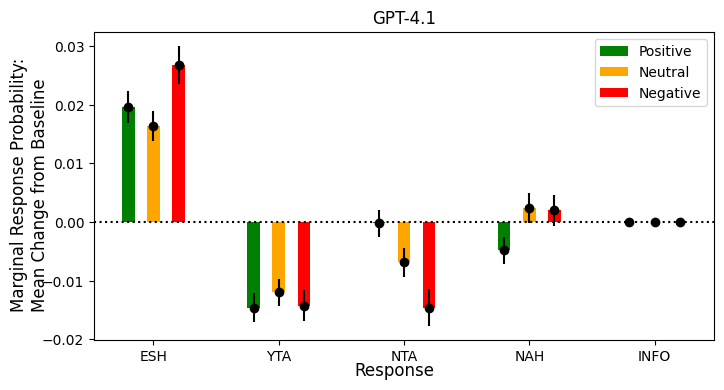

In [8]:
plot_bar_chart(
    keys=[
        # "gemma-3-4b-it norm bank",
        # "Llama-3.2-3B-Instruct norm bank",
        # "Qwen3-4B norm bank",
        "GPT-4.1 reddit probs",
    ],
    labels=[
        "GPT-4.1",
    ],
    output_filename="reddit diff",
    figsize=(8, 4)
)